In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px


In [2]:
total_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_K', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB']

preslectrion_keys = ['SUMCHI2','Cos_xi_LbP','Cos_xi_LP'] # ,'xi_LbP', 'xi_LP'



training_variables = total_keys+preslectrion_keys

In [3]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ'] + ['Lb_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data2 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS'],library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data3 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data4 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_data5 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data6 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data7 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data8 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")

mc_signal = mc_signal_merge
mc_bkg= mc_background_merge

#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal['Lb_CHI2']+mc_signal['L_CHI2']+mc_signal['Jpsi_CHI2']
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data
mc_signal['SUMCHI2'] = sum_CHI2
mc_signal['Cos_xi_LbP'] = cos_xi_L
mc_signal['Cos_xi_LP'] = cos_xi_Lb
# mc_signal['xi_LP'] = xi_L
# mc_signal['xi_LbP'] = xi_Lb

#Creates a new variables like the Cos()...
sum_CHI2 = mc_bkg['Lb_CHI2']+mc_bkg['L_CHI2']+mc_bkg['Jpsi_CHI2']
cos_xi_L = ((mc_bkg['p_PX']*mc_bkg['L_PX']+mc_bkg['p_PY']*mc_bkg['L_PY']+mc_bkg['p_PZ']*mc_bkg['L_PZ'])/(mc_bkg['p_P']*mc_bkg['L_P']))
cos_xi_Lb = ((mc_bkg['p_PX']*mc_bkg['Lb_PX']+mc_bkg['p_PY']*mc_bkg['Lb_PY']+mc_bkg['p_PZ']*mc_bkg['Lb_PZ'])/(mc_bkg['p_P']*mc_bkg['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data
mc_bkg['SUMCHI2'] = sum_CHI2
mc_bkg['Cos_xi_LP'] = cos_xi_L
mc_bkg['Cos_xi_LbP'] = cos_xi_Lb
# mc_bkg['xi_LP'] = xi_L
# mc_bkg['xi_LbP'] = xi_Lb



/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
data24_selected = pd.read_pickle('data24_training.pkl')

#Creates a new variables like the Cos()...
sum_CHI2_data = data24_selected['Lb_CHI2']+data24_selected['L_CHI2']+data24_selected['Jpsi_CHI2']
cos_xi_L_data = ((data24_selected['p_PX']*data24_selected['L_PX']+data24_selected['p_PY']*data24_selected['L_PY']+data24_selected['p_PZ']*data24_selected['L_PZ'])/(data24_selected['p_P']*data24_selected['L_P']))
cos_xi_Lb_data = ((data24_selected['p_PX']*data24_selected['Lb_PX']+data24_selected['p_PY']*data24_selected['Lb_PY']+data24_selected['p_PZ']*data24_selected['Lb_PZ'])/(data24_selected['p_P']*data24_selected['Lb_P']))
xi_L_data = np.arccos(cos_xi_L_data)
xi_Lb_data  = np.arccos(cos_xi_Lb_data)

#Add the new varaibles to signal_data
data24_selected['SUMCHI2'] = sum_CHI2_data
data24_selected['Cos_xi_LP'] = cos_xi_L_data
data24_selected['Cos_xi_LbP'] = cos_xi_Lb_data
# data24_selected['xi_LP'] = xi_L_data
# data24_selected['xi_LbP'] = xi_Lb_data

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
mc_signal

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,L_PX,L_PY,L_PZ,Lb_PX,Lb_PY,Lb_PZ,Lb_MASS,SUMCHI2,Cos_xi_LbP,Cos_xi_LP
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,-1182.349976,-1462.170044,73838.203125,-2058.070068,-1802.609985,195492.234375,5282.650391,7.188199,0.999784,0.999610
1,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,-3259.600098,-479.690002,51142.820312,-3174.320068,-415.829987,95583.171875,5621.771973,3.564506,0.999758,0.999945
2,36.637245,204.355850,0.999998,8.861835,1.525625,1.000000,0.013432,0.508896,2.389404,116028.679688,...,2730.510010,-1040.599976,64463.210938,2848.810059,-1108.760010,115988.398438,5729.892578,1.945351,0.999851,0.999986
3,38.721493,316.204285,0.999998,9.750591,0.333755,0.999998,0.008024,0.138330,9.783347,95800.343750,...,-1055.479980,2661.330078,42301.039062,-1029.310059,2846.820068,95752.500000,5583.860352,11.039947,0.999833,0.999369
4,46.746983,292.921631,0.999995,20.399487,4.260338,0.999996,0.050449,0.366285,18.198738,77709.648438,...,511.579987,4019.530029,89484.156250,-5.760000,1728.589966,77690.421875,5124.538086,11.015934,0.999989,0.999656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45186,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,2706.280029,-7570.799805,52268.058594,13297.400391,-52381.070312,396416.375000,5658.234863,1.460683,0.999895,0.999932
45187,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,5113.750000,12735.139648,92244.421875,27811.560547,50732.710938,415538.562500,5682.604492,10.375792,0.999991,0.999856
45188,52586.535156,1454.460693,1.000000,1.240632,0.044432,0.999993,0.018205,1.080854,1.140757,305247.031250,...,-15177.339844,9716.740234,81843.101562,-60551.750000,36547.660156,296940.218750,6174.708496,7.922751,0.999977,0.999699
45189,56073.160156,659.730225,1.000000,4.729567,1.089546,1.000000,0.027986,3.200937,4.553952,843898.875000,...,34217.699219,-20374.349609,347540.531250,77827.031250,-46802.281250,838998.125000,5967.574219,1.201591,1.000000,0.999976


In [6]:
mc_bkg

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,L_PX,L_PY,L_PZ,Lb_PX,Lb_PY,Lb_PZ,Lb_MASS,SUMCHI2,Cos_xi_LP,Cos_xi_LbP
0,6.139585,91.591812,0.999991,21.584637,5.397385,0.996216,0.089235,0.084741,11.567128,86401.679688,...,-644.349976,-1046.880005,58653.031250,-407.190002,-940.929993,86395.593750,6054.324219,10.848227,0.998823,0.999065
1,6.139585,91.591812,0.999991,21.584637,5.397385,0.996216,0.089235,0.084741,11.567128,86401.679688,...,-644.349976,-1046.880005,58653.031250,-407.190002,-940.929993,86395.593750,5999.031250,10.848227,0.999495,0.999267
2,19.314734,135.128021,0.999997,11.173959,0.388747,0.999982,0.052048,0.162292,8.909716,188634.140625,...,-1494.540039,-1340.329956,69781.617188,-1997.630005,-1629.599976,188616.515625,5688.728027,0.843840,0.999882,0.999606
3,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,-1182.349976,-1462.170044,73838.203125,-2058.070068,-1802.609985,195492.234375,5899.578613,7.188199,0.998826,0.998984
4,19.314734,185.730194,0.999997,14.878242,10.207611,0.999964,0.073177,0.161870,9.451078,164147.312500,...,-985.750000,-1412.300049,57646.671875,-1018.239990,-1342.400024,164138.671875,5344.718750,19.892063,0.998892,0.998168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131511,45742.613281,432.337402,0.999995,8.839814,2.762513,1.000000,0.009735,5.190244,1.035346,388142.187500,...,-5516.799805,2723.520020,38707.089844,-44914.601562,24853.900391,384732.812500,5837.273926,5.612118,0.999124,0.997726
131512,49578.726562,675.056152,0.999584,93.922745,27.925442,0.999995,0.061441,3.870095,32.689659,312018.937500,...,4326.979980,11728.599609,56808.101562,11983.290039,59515.339844,306055.781250,5710.352539,32.092987,0.999942,0.998845
131513,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,-152.289993,-4749.979980,63607.910156,4489.120117,-63733.871094,864902.937500,5969.040039,6.704729,0.999704,0.999491
131514,62705.792969,599.821411,1.000000,1.735334,0.047637,1.000000,0.005665,9.711040,4.410466,531780.250000,...,23778.410156,3421.469971,155042.515625,83440.812500,6573.799805,525152.062500,5597.971191,1.642224,0.999980,0.999958


In [7]:
data24_selected.columns

Index(['Jpsi_PT', 'Jpsi_CHI2', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP',
       'L_BPVIPCHI2', 'Lb_MASS', 'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO',
       'Lb_MAXDOCA', 'Lb_P', 'Lb_PT', 'Lb_CHI2', 'p_PID_K', 'p_MINIP',
       'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA', 'Lb_MINIPCHI2', 'L_P',
       'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ', 'L_END_VX', 'L_END_VY',
       'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA', 'p_GHOSTPROB', 'pim_P', 'pim_PT',
       'pim_ETA', 'pim_GHOSTPROB', 'p_PX', 'p_PY', 'p_PZ', 'L_PX', 'L_PY',
       'L_PZ', 'Lb_PX', 'Lb_PY', 'Lb_PZ', 'SUMCHI2', 'Cos_xi_LP',
       'Cos_xi_LbP'],
      dtype='object')

In [8]:
print(len(training_variables))

37


In [9]:
to_drop1 = [x for x in mc_signal.columns if x not in training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']]
to_drop2 = [x for x in mc_bkg.columns if x not in training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']]
to_drop3 = [x for x in data24_selected.columns if x not in training_variables + ['Lb_MASS']]

In [10]:
print(to_drop3)

['Jpsi_CHI2', 'p_PX', 'p_PY', 'p_PZ', 'L_PX', 'L_PY', 'L_PZ', 'Lb_PX', 'Lb_PY', 'Lb_PZ']


In [11]:
mc_signal.drop(columns=to_drop1, inplace=True)
mc_bkg.drop(columns=to_drop2, inplace=True)
data24_selected.drop(columns=to_drop3, inplace=True)

In [12]:
mc_signal

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SUMCHI2,Cos_xi_LbP,Cos_xi_LP
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,24223.253906,963.351562,3.917370,0.133526,0,3736.9928,5282.650391,7.188199,0.999784,0.999610
1,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,6361.758789,1335.411743,2.242929,0.008439,0,3245.1502,5621.771973,3.564506,0.999758,0.999945
2,36.637245,204.355850,0.999998,8.861835,1.525625,1.000000,0.013432,0.508896,2.389404,116028.679688,...,15605.727539,1525.975708,3.015725,0.001091,0,4151.9955,5729.892578,1.945351,0.999851,0.999986
3,38.721493,316.204285,0.999998,9.750591,0.333755,0.999998,0.008024,0.138330,9.783347,95800.343750,...,5954.875977,924.584106,2.549647,0.003497,0,4704.0581,5583.860352,11.039947,0.999833,0.999369
4,46.746983,292.921631,0.999995,20.399487,4.260338,0.999996,0.050449,0.366285,18.198738,77709.648438,...,8986.731445,485.259430,3.611147,0.005654,0,6283.1480,5124.538086,11.015934,0.999989,0.999656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45186,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,8622.672852,1662.371460,2.329843,0.019437,0,5390.6936,5658.234863,1.460683,0.999895,0.999932
45187,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,10248.884766,1338.006836,2.724765,0.021807,0,5891.9254,5682.604492,10.375792,0.999991,0.999856
45188,52586.535156,1454.460693,1.000000,1.240632,0.044432,0.999993,0.018205,1.080854,1.140757,305247.031250,...,12177.336914,3035.123047,2.066535,0.002588,0,5499.6822,6174.708496,7.922751,0.999977,0.999699
45189,56073.160156,659.730225,1.000000,4.729567,1.089546,1.000000,0.027986,3.200937,4.553952,843898.875000,...,59026.421875,6539.232910,2.890138,0.030829,0,6307.0466,5967.574219,1.201591,1.000000,0.999976


In [13]:
mc_bkg

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SUMCHI2,Cos_xi_LP,Cos_xi_LbP
0,6.139585,91.591812,0.999991,21.584637,5.397385,0.996216,0.089235,0.084741,11.567128,86401.679688,...,34398.105469,1564.276855,3.783211,0.025993,110,3793.4833,6054.324219,10.848227,0.998823,0.999065
1,6.139585,91.591812,0.999991,21.584637,5.397385,0.996216,0.089235,0.084741,11.567128,86401.679688,...,22625.416016,964.715149,3.847692,0.002822,110,2683.7291,5999.031250,10.848227,0.999495,0.999267
2,19.314734,135.128021,0.999997,11.173959,0.388747,0.999982,0.052048,0.162292,8.909716,188634.140625,...,5161.642578,887.622559,2.446131,0.395810,110,3736.9928,5688.728027,0.843840,0.999882,0.999606
3,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,63092.632812,2604.745850,3.879981,0.085652,30,3736.9928,5899.578613,7.188199,0.998826,0.998984
4,19.314734,185.730194,0.999997,14.878242,10.207611,0.999964,0.073177,0.161870,9.451078,164147.312500,...,24223.253906,963.351562,3.917370,0.133526,100,2809.9247,5344.718750,19.892063,0.998892,0.998168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131511,45742.613281,432.337402,0.999995,8.839814,2.762513,1.000000,0.009735,5.190244,1.035346,388142.187500,...,7469.713379,539.848877,3.319077,0.011858,0,1103.2798,5837.273926,5.612118,0.999124,0.997726
131512,49578.726562,675.056152,0.999584,93.922745,27.925442,0.999995,0.061441,3.870095,32.689659,312018.937500,...,27045.894531,5722.893066,2.234740,0.482203,110,1779.2390,5710.352539,32.092987,0.999942,0.998845
131513,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,7028.527344,1471.611450,2.245543,0.000829,0,867.2470,5969.040039,6.704729,0.999704,0.999491
131514,62705.792969,599.821411,1.000000,1.735334,0.047637,1.000000,0.005665,9.711040,4.410466,531780.250000,...,18638.310547,2051.989258,2.896415,0.008817,50,3807.4799,5597.971191,1.642224,0.999980,0.999958


In [14]:
data24_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_MASS,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,...,p_PT,p_ETA,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,SUMCHI2,Cos_xi_LP,Cos_xi_LbP
0,3598.771240,156.148010,0.999989,14.993918,0.740069,5381.645508,0.999808,0.172147,0.743518,11.071568,...,519.947083,4.720314,0.022217,10264.916992,1558.992798,2.571969,0.034511,1.403328,0.999292,0.997688
1,1651.993286,412.306061,0.999967,42.544411,30.133858,5690.910156,0.997083,0.122188,0.118988,36.286690,...,3213.287842,2.987015,0.020499,3542.490723,565.024963,2.522418,0.049933,44.052173,0.999678,0.996826
2,692.289978,177.445908,0.999842,46.355751,15.645406,5145.699707,0.999863,0.073200,0.051784,44.803188,...,2575.188721,2.976051,0.196051,5615.358887,1182.498413,2.239669,0.361459,27.619172,0.998498,0.996228
3,1998.845215,123.014687,0.999933,48.047382,34.940838,5366.872559,0.999948,0.078248,0.229810,6.426580,...,794.056641,4.613406,0.559615,5485.895996,1042.090088,2.344929,0.027113,38.596400,0.999756,0.999609
4,3398.809570,90.898071,0.999950,38.231625,16.379837,5437.650391,0.999850,0.028972,0.061120,16.201925,...,1972.021851,3.976324,0.001780,6743.292969,900.394409,2.702041,0.014259,15.778711,0.999825,0.998003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2385520,4744.859375,132.047379,0.999930,42.987904,1.812658,5792.686035,0.999929,0.040655,0.053835,11.496815,...,20796.503906,3.546215,0.807977,11243.829102,1019.649902,3.091441,0.354275,7.760226,0.999907,0.997539
2385521,4744.859375,194.405609,0.999960,25.600740,1.545042,6279.723633,0.999803,0.044070,0.092652,25.436529,...,4892.478027,3.177253,0.415006,6351.302734,1082.581055,2.455120,0.336821,22.248538,0.999629,0.998579
2385522,4744.859375,104.449326,0.999818,60.250225,39.987339,5294.475586,0.999973,0.025166,0.053659,30.978270,...,2488.817871,4.011059,0.453906,7860.812012,735.051331,3.060646,0.588539,40.806155,0.999927,0.999824
2385523,4744.859375,153.686218,0.999969,29.496040,9.275840,5411.514648,0.999805,0.043789,0.092558,33.179039,...,2642.075684,3.773958,0.379995,7723.580078,800.931091,2.956642,0.499999,20.990757,0.999885,0.999856


In [15]:
training_data = mc_signal.merge(mc_bkg.sample(len(mc_signal)),how='outer')
training_data

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SUMCHI2,Cos_xi_LbP,Cos_xi_LP
0,6.139585,91.591812,0.999991,21.584637,5.397385,0.996216,0.089235,0.084741,11.567128,86401.679688,...,22625.416016,964.715149,3.847692,0.002822,110,2683.7291,5999.031250,10.848227,0.999267,0.999495
1,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,24223.253906,963.351562,3.917370,0.133526,0,3736.9928,5282.650391,7.188199,0.999784,0.999610
2,19.314734,185.730194,0.999997,14.878242,10.207611,0.999964,0.073177,0.161870,9.451078,164147.312500,...,25560.128906,1764.792847,3.364853,0.005164,100,3736.9928,5371.487305,19.892063,0.999145,0.998778
3,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,9799.946289,333.520447,4.073184,0.015913,110,5116.3571,5012.679688,3.840920,0.999238,0.999909
4,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,6361.758789,1335.411743,2.242929,0.008439,0,3245.1502,5621.771973,3.564506,0.999758,0.999945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90377,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,10248.884766,1338.006836,2.724765,0.021807,0,5891.9254,5682.604492,10.375792,0.999991,0.999856
90378,52586.535156,1454.460693,1.000000,1.240632,0.044432,0.999993,0.018205,1.080854,1.140757,305247.031250,...,12177.336914,3035.123047,2.066535,0.002588,0,5499.6822,6174.708496,7.922751,0.999977,0.999699
90379,56073.160156,659.730225,1.000000,4.729567,1.089546,1.000000,0.027986,3.200937,4.553952,843898.875000,...,59026.421875,6539.232910,2.890138,0.030829,0,6307.0466,5967.574219,1.201591,1.000000,0.999976
90380,66453.953125,819.527710,0.999999,7.625220,1.552067,1.000000,0.007629,4.088942,0.801441,468259.125000,...,10165.380859,1665.704590,2.495097,0.001723,50,5702.4261,5670.506836,2.974337,0.999686,0.999977


In [16]:
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500)
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True


In [17]:
new_training = pd.DataFrame(columns=training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6450) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_27012/2330259369.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [18]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [19]:
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS']

In [20]:
X_tr, X_eval = train_test_split(new_training)
y_tr = X_tr.SIGNAL
y_tr_clean = y_tr == True
X_tr_copy = X_tr.copy()
X_tr.drop(columns=to_drop, inplace=True)

In [21]:
y_eval =  X_eval.SIGNAL
y_eval_clean = y_eval == True
X_eval_copy = X_eval.copy()
X_eval.drop(columns=to_drop, inplace=True)

In [22]:
X_eval.columns

Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_K', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'Cos_xi_LbP', 'Cos_xi_LP'],
      dtype='object')

In [23]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced'
}

In [24]:
train_dataset = Pool(X_tr, y_tr_clean, feature_names=list(X_tr.columns))
eval_dataset = Pool(X_eval, y_eval_clean, feature_names=list(X_eval.columns))

In [25]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=True, plot=False)

Learning rate set to 0.064837
0:	learn: 0.5581688	total: 62.7ms	remaining: 1m 2s
1:	learn: 0.4523114	total: 78ms	remaining: 38.9s
2:	learn: 0.3785100	total: 90.8ms	remaining: 30.2s
3:	learn: 0.3214729	total: 101ms	remaining: 25.2s
4:	learn: 0.2742570	total: 112ms	remaining: 22.3s
5:	learn: 0.2404977	total: 122ms	remaining: 20.2s
6:	learn: 0.2136559	total: 132ms	remaining: 18.7s
7:	learn: 0.1901006	total: 143ms	remaining: 17.7s
8:	learn: 0.1734155	total: 155ms	remaining: 17s
9:	learn: 0.1586988	total: 165ms	remaining: 16.3s
10:	learn: 0.1467216	total: 176ms	remaining: 15.8s
11:	learn: 0.1364429	total: 186ms	remaining: 15.3s
12:	learn: 0.1276951	total: 197ms	remaining: 14.9s
13:	learn: 0.1198489	total: 207ms	remaining: 14.6s
14:	learn: 0.1132989	total: 217ms	remaining: 14.3s
15:	learn: 0.1073195	total: 228ms	remaining: 14s
16:	learn: 0.1023600	total: 238ms	remaining: 13.8s
17:	learn: 0.0984706	total: 248ms	remaining: 13.5s
18:	learn: 0.0950889	total: 259ms	remaining: 13.4s
19:	learn: 0.0

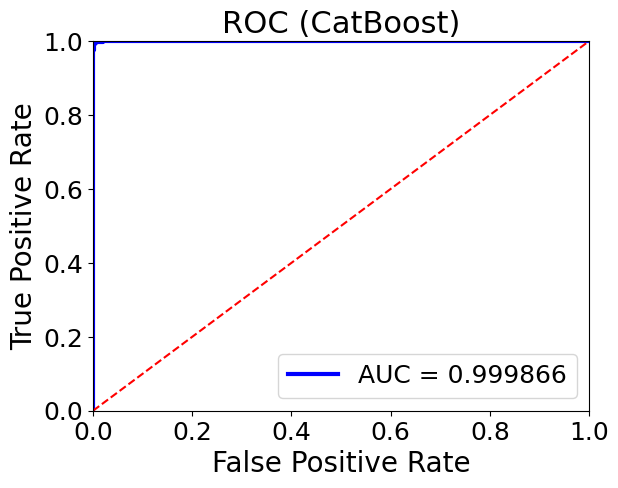

In [26]:
import sklearn.metrics as metrics
probs = model.predict_proba(X_eval)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_eval, preds)
roc_auc = metrics.auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.title('ROC (CatBoost)', fontsize=22)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=3)
plt.legend(loc = 'lower right', fontsize=18)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=20)
plt.xlabel('False Positive Rate', fontsize=20)
plt.xticks(fontsize=18) 
plt.yticks(fontsize=18) 
plt.show()

In [27]:
print(model.get_best_score())
print(model.get_all_params())


{'learn': {'Accuracy:use_weights=true': 0.9997631162480596, 'Logloss:use_weights=false': 0.00478583073210951, 'Logloss:use_weights=true': 0.00478003190782355, 'Logloss': 0.00478003190782355, 'Accuracy:use_weights=false': 0.9997577062861758, 'AUC': 0.9999996506301064}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 'ra

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'L_END_VY'),
  Text(0, 1, 'Jpsi_MAXDOCA'),
  Text(0, 2, 'Lb_MAXDOCA'),
  Text(0, 3, 'L_END_VX'),
  Text(0, 4, 'p_PID_K'),
  Text(0, 5, 'L_CHI2'),
  Text(0, 6, 'Lb_CHI2'),
  Text(0, 7, 'p_P'),
  Text(0, 8, 'L_BPVIP'),
  Text(0, 9, 'pim_ETA'),
  Text(0, 10, 'Lb_PT'),
  Text(0, 11, 'L_BPVDIRA'),
  Text(0, 12, 'p_PT'),
  Text(0, 13, 'L_END_VZ'),
  Text(0, 14, 'Lb_P'),
  Text(0, 15, 'L_BPVIPCHI2'),
  Text(0, 16, 'Lb_BPVVDRHO'),
  Text(0, 17, 'p_ETA'),
  Text(0, 18, 'L_PT'),
  Text(0, 19, 'L_P'),
  Text(0, 20, 'Jpsi_BPVDIRA'),
  Text(0, 21, 'mup_PID_MU'),
  Text(0, 22, 'Jpsi_PT'),
  Text(0, 23, 'Lb_MINIPCHI2'),
  Text(0, 24, 'pim_GHOSTPROB'),
  Text(0, 25, 'pim_P'),
  Text(0, 26, 'pim_PT'),
  Text(0, 27, 'Lb_ETA'),
  Text(0, 28, 'p_GHOSTPROB'),
  Text(0, 29, 'Lb_BPVIP')

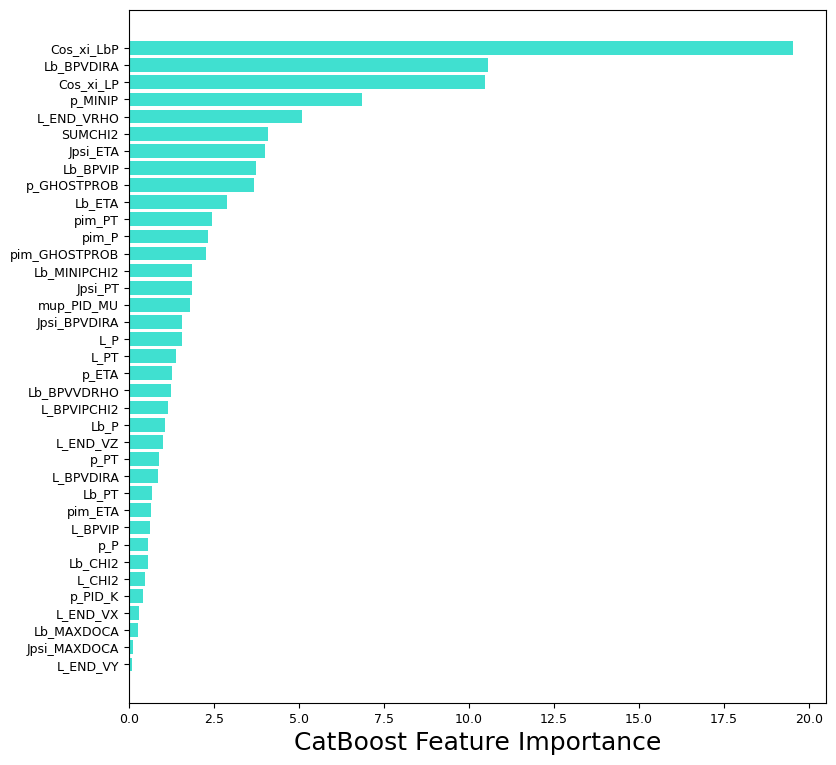

In [28]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (9,9)
plt.barh(X_eval.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("CatBoost Feature Importance", fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
plt.xticks(fontsize=9)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=9)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

In [29]:
signal_MVA_prob_eval = model.predict_proba(X_eval_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
X_eval_copy['signal_MVA'] = signal_MVA_probs

signal_MVA_prob_tr = model.predict_proba(X_tr_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_tr]
X_tr_copy['signal_MVA'] = signal_MVA_probs

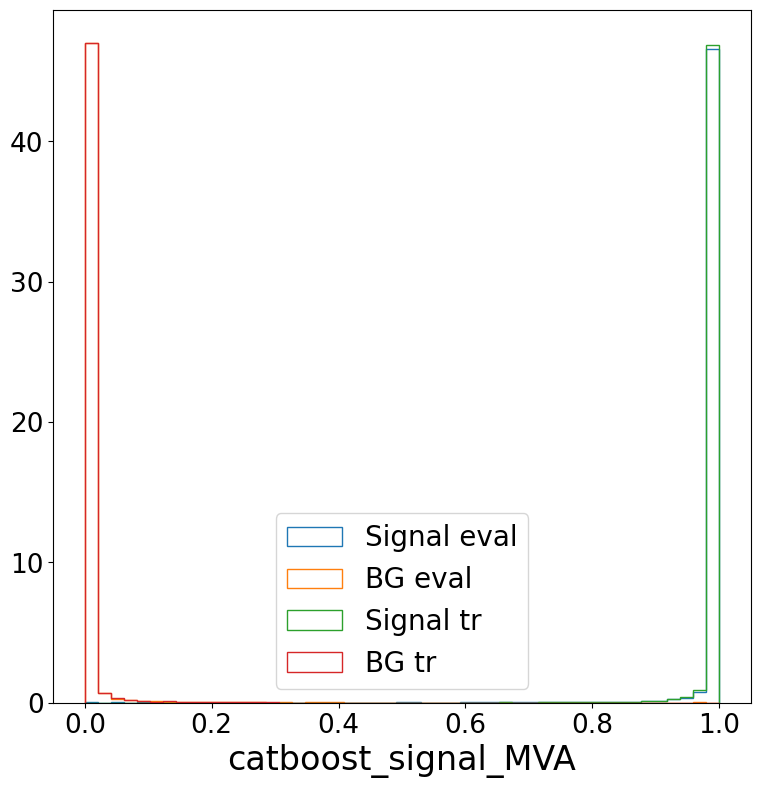

In [30]:
fig, ax = plt.subplots()

density = True

variable = 'signal_MVA'

bins = np.linspace(0,1,50)

n_sig,bins_sig, _ = ax.hist(X_eval_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal eval",histtype='step',density=density)
n_bg,bins_bg, _ = ax.hist(X_eval_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG eval",histtype='step',density=density)

ax.hist(X_tr_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal tr",histtype='step',density=density)
ax.hist(X_tr_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG tr",histtype='step',density=density)

ax.legend(fontsize=20)  # Ajusta el tamaño de fuente de la leyenda
ax.set_xlabel("catboost_signal_MVA", fontsize=24)  # Ajusta el tamaño de fuente del eje x

# Ajusta el tamaño de fuente de las marcas en los ejes x e y
ax.tick_params(axis='both', which='major', labelsize=19)

plt.show()

In [31]:
model.save_model('new_BDT_2',
           format="cbm",
           export_parameters=None,
           pool=None)